In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')
rdir = '/home/kat/Repos/SALSA/results/'

### Load umapped evaluation dataset.

In [2]:
# # # # # # # # # # # 
# tag = '2022041804_04_1000n_test_32neigh_mindist0pt1'
tag = '2022041809_a04_1000n_test_32neigh_mindist0pt1'
# # # # # # # # # # # 

import pandas as pd
from rdkit.Chem import PandasTools

df = pd.read_csv(f'{rdir}umap_dfs/{tag}.csv')
PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
df = df[["Smiles","Mol","Label","Atype","x","y"]]


### Sort by number of atoms.

In [3]:
from utilities.rdkit_utils import *
df['atom_cnt'] = df.Smiles.apply(lambda x: count_atoms(x))
df = df.sort_values(by='atom_cnt')

In [4]:
samp_size = 20
df_samp = df[:samp_size]
# df_samp

### Inspect n smallest molecules. (Use this set for prototyping.)

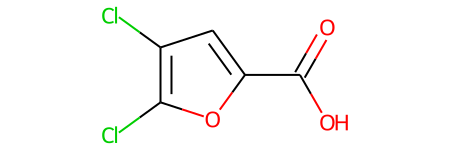

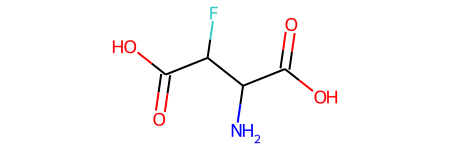

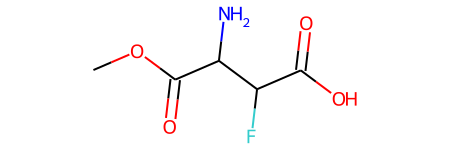

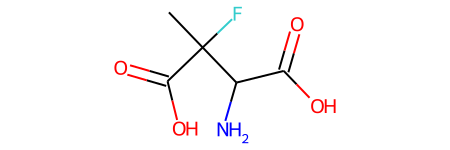

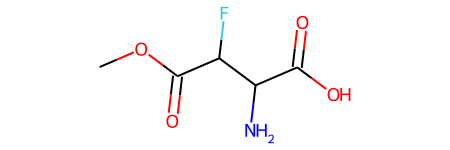

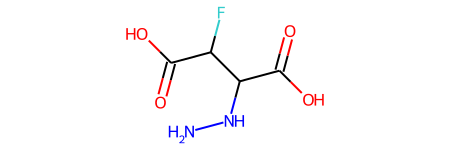

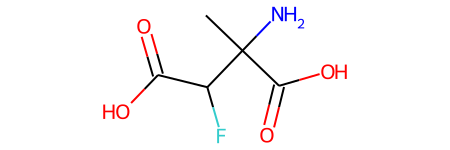

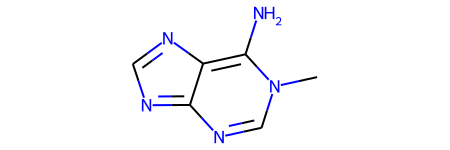

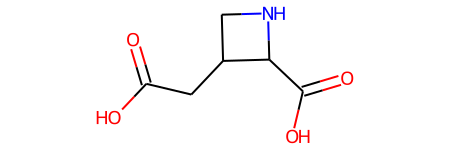

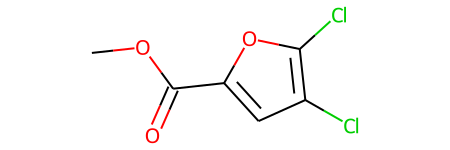

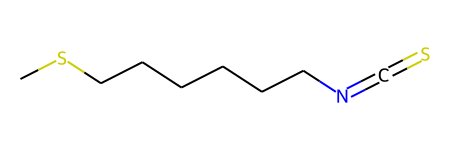

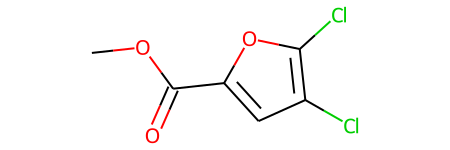

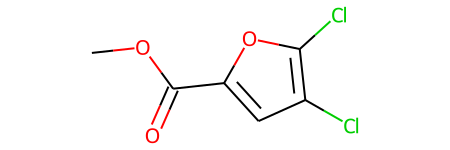

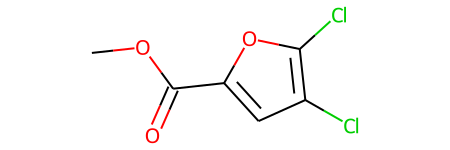

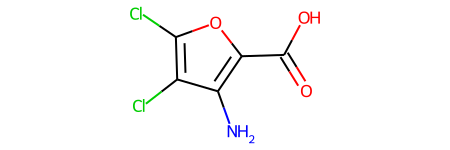

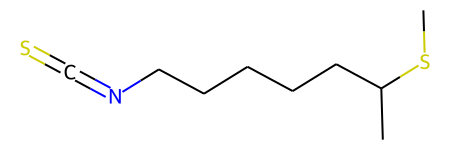

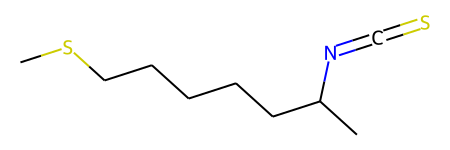

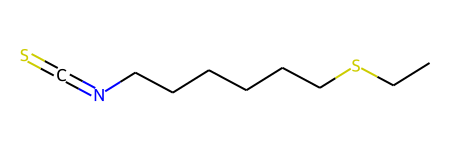

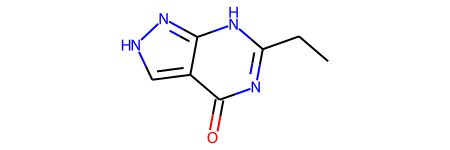

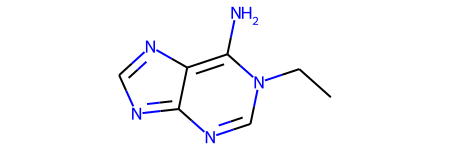

In [5]:
def sm_and_mol(sm):
    mol = Chem.MolFromSmiles(sm)
    sm = Chem.MolToSmiles(mol)
    display(sm,mol)
    
mols = df_samp.Mol.values

for m in mols:
    display(m)

### Convert mols to graphs ...

In [6]:
from rdkit import Chem
import networkx as nx

bond_type_dict = {Chem.rdchem.BondType.ZERO: "ZERO",
                  Chem.rdchem.BondType.SINGLE: "SING","1": "SING",
                  "am": "SING","un": "SING",
                  Chem.rdchem.BondType.DOUBLE: "DOUB","2": "DOUB",
                  Chem.rdchem.BondType.TRIPLE: "TRIP", "3": "TRIP",
                  Chem.rdchem.BondType.AROMATIC: "AROM", "ar": "AROM"}

def rdkit_2_nx(mol, element_label="", keep_ids=None):
    # convert a rdkit mol to a networkx graph
    g = nx.Graph()
#     conformer = mol.GetConformer()
    for atom in mol.GetAtoms():
        g.add_node(str(atom.GetIdx()),
                   atomic_num=atom.GetAtomicNum(),
                   formal_charge=atom.GetFormalCharge(),
                   chiral_tag=None,
                   hybridization=atom.GetHybridization(),
                   num_explicit_hs=atom.GetNumExplicitHs(),
                   is_aromatic=atom.GetIsAromatic(),
                   element=atom.GetSymbol() + element_label,
#                    coords=tuple(conformer.GetAtomPosition(atom.GetIdx())),
                   atom_index=int(atom.GetIdx()))
        
    for bond in mol.GetBonds():
        if bond.GetBondType() == Chem.rdchem.BondType.ZERO:
            continue
        g.add_edge(str(bond.GetBeginAtomIdx()),
                   str(bond.GetEndAtomIdx()),
                   bond_type=bond_type_dict[bond.GetBondType()])
    return g

In [7]:
gs = []
for row in df_samp.itertuples():
    try:
        mol = row.Mol
        graph = rdkit_2_nx(mol)
        gs.append(graph)
    except Exception as e:
        print(e)
        continue

### Find edit distances between all pairs ... 

In [8]:
# james graph matching function ... 
def categorical_match(attr, default):
    if isinstance(attr, str):
        def match(data1, data2):
            data1_attr = data1.get(attr, default)
            data2_attr = data2.get(attr, default)
            return data1_attr == data2_attr
    else:
        attrs = list(zip(attr, default))
        def match(data1, data2):
            bools = []
            for attr, d in attrs:
                data1_attr = data1.get(attr, default)
                data2_attr = data2.get(attr, default)
                bools.append(data1_attr == data2_attr)
            return all(bools)

    return match

em = categorical_match("bond_type", None)
nm = categorical_match("element", None)

In [9]:
from tqdm.notebook import tqdm
from itertools import combinations as combo
from datetime import datetime

all_dists = []

i = 0
start = datetime.now()
s = start
    
for idc_pair in tqdm(combo(range(len(gs)),2), total=len(gs)**2//2-len(gs)):
    
    idx1, idx2 = idc_pair
    if idx1==idx2:
        continue
    
    g1 = gs[idx1]    
    g2 = gs[idx2]  
    
    try:
        d = nx.graph_edit_distance(g1, g2, node_match=nm, edge_match=em)
    except Exception as e:
        print(e)
        continue

    e = datetime.now()
    lap = e - s
    s = e
    print(f"Iter {i} done. Time: {lap.seconds//60%60} mins " +\
    f"{lap.seconds%60} secs. -- Distance: {d}")
    
    i+=1
    print(d)
    
    all_dists.append(d)
    
print(len(all_dists))

  0%|          | 0/200 [00:00<?, ?it/s]

Iter 0 done. Time: 0 mins 0 secs. -- Distance: 9.0
9.0
Iter 1 done. Time: 0 mins 5 secs. -- Distance: 11.0
11.0
Iter 2 done. Time: 0 mins 2 secs. -- Distance: 10.0
10.0
Iter 3 done. Time: 0 mins 5 secs. -- Distance: 11.0
11.0
Iter 4 done. Time: 0 mins 2 secs. -- Distance: 11.0
11.0
Iter 5 done. Time: 0 mins 2 secs. -- Distance: 10.0
10.0
Iter 6 done. Time: 4 mins 28 secs. -- Distance: 15.0
15.0
Iter 7 done. Time: 0 mins 0 secs. -- Distance: 10.0
10.0
Iter 8 done. Time: 0 mins 0 secs. -- Distance: 2.0
2.0
Iter 9 done. Time: 3 mins 2 secs. -- Distance: 15.0
15.0
Iter 10 done. Time: 0 mins 0 secs. -- Distance: 2.0
2.0
Iter 11 done. Time: 0 mins 0 secs. -- Distance: 2.0
2.0
Iter 12 done. Time: 0 mins 0 secs. -- Distance: 2.0
2.0
Iter 13 done. Time: 0 mins 0 secs. -- Distance: 2.0
2.0
Iter 14 done. Time: 5 mins 24 secs. -- Distance: 17.0
17.0
Iter 15 done. Time: 5 mins 4 secs. -- Distance: 17.0
17.0
Iter 16 done. Time: 5 mins 32 secs. -- Distance: 17.0
17.0
Iter 17 done. Time: 0 mins 50 sec

KeyboardInterrupt: 